# Convert raw data to 'strict' json

In [1]:
import json
import gzip
import os
dataset_name = "Beauty"
os.makedirs(dataset_name, exist_ok=True)

def parse(path):
  g = gzip.open(path, 'r')
  for l in g:
    yield json.dumps(eval(l))

# Beauty dataset
f = open(f"./{dataset_name}/{dataset_name}.json", 'w')
for l in parse(f"reviews_{dataset_name}_5.json.gz"):
  f.write(l + '\n')

In [2]:
# print the number of lines in the file and the first line
data = open(f"./{dataset_name}/{dataset_name}.json", 'r')
print("Number of lines:", sum(1 for _ in data))
data.seek(0)  # Reset file pointer to the beginning
print("First line:", data.readline().strip())
data.close()

Number of lines: 198499
First line: {"reviewerID": "A1YJEY40YUW4SE", "asin": "7806397051", "reviewerName": "Andrea", "helpful": [3, 4], "reviewText": "Very oily and creamy. Not at all what I expected... ordered this to try to highlight and contour and it just looked awful!!! Plus, took FOREVER to arrive.", "overall": 1.0, "summary": "Don't waste your money", "unixReviewTime": 1391040000, "reviewTime": "01 30, 2014"}


In [3]:
# 建立userid-user索引、itemid-item索引、user索引-item索引的映射
# 得到：
# 1. user_mapping.npy：用户索引映射
# 2. item_mapping.npy：物品索引映射
# 3. train/valid/test.parquet：用户物品交互序列
import numpy as np
import pandas as pd

# Initialize mapping dictionaries
userID_mapping = {}
itemID_mapping = {}

# Open the JSON file for reading
data = open(f"./{dataset_name}/{dataset_name}.json", 'r')

# Initialize lists to store userID, itemID, and timestamp
userIDs = []
itemIDs = []
timestamps = []

# Process each line in the JSON file
for line in data:
    review = json.loads(line.strip())
    userID = review['reviewerID']
    itemID = review['asin']
    timestamp = review['unixReviewTime']
    
    # Map userID to an integer starting from 1 索引从1开始
    if userID not in userID_mapping:
        userID_mapping[userID] = len(userID_mapping) + 1
    
    # Map itemID to an integer starting from 1 索引从1开始
    if itemID not in itemID_mapping:
        itemID_mapping[itemID] = len(itemID_mapping) + 1
    
    # Append mapped values and timestamp to lists 这里添加的已经是索引，不是原始的userID/itemID
    userIDs.append(userID_mapping[userID])
    itemIDs.append(itemID_mapping[itemID])
    timestamps.append(timestamp)

# Save mapping dictionaries as .npy files
np.save(f'./{dataset_name}/user_mapping.npy', userID_mapping)
print("user_num:", len(userID_mapping))
print("the first five userID mapping:", list(userID_mapping.items())[:5])
np.save(f'./{dataset_name}/item_mapping.npy', itemID_mapping)
print("item_num:", len(itemID_mapping))
print("the first five itemID mapping:", list(itemID_mapping.items())[:5])

# Group itemIDs by userID and sort by timestamp 构建user-item交互序列
user_item_mapping = {}
for userID, itemID, timestamp in zip(userIDs, itemIDs, timestamps):
    if userID not in user_item_mapping:
        user_item_mapping[userID] = []
    user_item_mapping[userID].append((itemID, timestamp))

# Sort itemIDs for each user by timestamp
for userID in user_item_mapping:
    user_item_mapping[userID].sort(key=lambda x: x[1])
    user_item_mapping[userID] = [item[0] for item in user_item_mapping[userID]]  # 去掉timestamp，只保留itemID序列

# Print a sample of the results
print("user-item mapping:", list(user_item_mapping.items())[:5])

# Split data into training, validation, and testing sets using leave-one-out strategy
train_data = {}
val_data = {}
test_data = {}

# !!! 这样分配训练/验证/测试集是合理的，从时序预测的角度去理解
# 前缀重叠是时序预测的固有属性，不是泄露。保证公平性的底线是 (history, target) 这个完整对不跨集合重复，而时序划分满足这一点。
for userID, item_sequence in user_item_mapping.items():  # 这里的userID已经是索引（从1开始）而非原始ID
    # Assign the last item for testing, the second-to-last for validation, and the rest for training
    train_data[userID] = item_sequence[:-2]
    val_data[userID] = item_sequence[:-1]
    test_data[userID] = item_sequence

# Print a sample of the split data
print("training data:", list(train_data.items())[:5])
print("validation data:", list(val_data.items())[:5])
print("testing data:", list(test_data.items())[:5])

# Prepare data for train, validation, and test sets
def prepare_data(data_dict):  # leave-one-out 划分历史和目标
    """
    整理成{userID, history list, target}的样本形式，返回字典列表
    """
    rows = []
    for userID, item_sequence in data_dict.items():
        history = item_sequence[:-1]
        target = item_sequence[-1]
        rows.append({'user': userID, 'history': history, 'target': target})
    return pd.DataFrame(rows)

# Create dataframes for train, validation, and test sets
train_df = prepare_data(train_data)
print("\nTraining data shape:", train_df.shape)
print("the first 3 rows of training data:\n", train_df.head(3))
val_df = prepare_data(val_data)
print("\nValidation data shape:", val_df.shape)
print("the first 3 rows of validation data:\n", val_df.head(3))
test_df = prepare_data(test_data)
print("\nTesting data shape:", test_df.shape)
print("the first 3 rows of testing data:\n", test_df.head(3))

# Save dataframes to parquet files
train_df.to_parquet(f'./{dataset_name}/train.parquet', index=False)
val_df.to_parquet(f'./{dataset_name}/valid.parquet', index=False)
test_df.to_parquet(f'./{dataset_name}/test.parquet', index=False)

print("Data saved to parquet files.")

data.close()

# 数据集	history（历史交互）	        target（预测目标）	用途
# 训练集	[item1, item2]	                 item3	    学习用户偏好
# 验证集	[item1, item2, item3]	         item4	    调参、选择模型
# 测试集	[item1, item2, item3, item4]	 item5	    评估最终性能



user_num: 22363
the first five userID mapping: [('A1YJEY40YUW4SE', 1), ('A60XNB876KYML', 2), ('A3G6XNM240RMWA', 3), ('A1PQFP6SAJ6D80', 4), ('A38FVHZTNQ271F', 5)]
item_num: 12101
the first five itemID mapping: [('7806397051', 1), ('9759091062', 2), ('9788072216', 3), ('9790790961', 4), ('9790794231', 5)]
user-item mapping: [(1, [6846, 7873, 4585, 1, 5406]), (2, [816, 10406, 11194, 11651, 9716, 1, 233]), (3, [1, 6050, 7977, 5252, 4211, 243, 11204, 5863, 6609]), (4, [5522, 439, 5161, 11140, 1, 7849]), (5, [1, 10470, 10064, 9403, 10362, 4758, 6500, 11444, 11390])]
training data: [(1, [6846, 7873, 4585]), (2, [816, 10406, 11194, 11651, 9716]), (3, [1, 6050, 7977, 5252, 4211, 243, 11204]), (4, [5522, 439, 5161, 11140]), (5, [1, 10470, 10064, 9403, 10362, 4758, 6500])]
validation data: [(1, [6846, 7873, 4585, 1]), (2, [816, 10406, 11194, 11651, 9716, 1]), (3, [1, 6050, 7977, 5252, 4211, 243, 11204, 5863]), (4, [5522, 439, 5161, 11140, 1]), (5, [1, 10470, 10064, 9403, 10362, 4758, 6500, 11444]

  Beauty 数据集概览
  用户数:  22363
  物品数:  12101
  交互数:  67089
  训练样本: 22363  (用户 × leave-one-out)
  验证样本: 22363
  测试样本: 22363

───────────────────────────────────────────────────────
  2. 序列长度分布 (原始用户交互序列)
───────────────────────────────────────────────────────
  train: min=3, max=202, mean=6.9, median=4
  valid: min=4, max=203, mean=7.9, median=5
  test: min=5, max=204, mean=8.9, median=6


/tmp/ipykernel_3573/3963351536.py:63: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3573/3963351536.py:63: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3573/3963351536.py:63: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3573/3963351536.py:63: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3573/3963351536.py:64: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  plt.savefig(f'./{dataset_name}/seq_length_dist.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3573/3963351536.py:64: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  plt.savefig(f'./{dataset_name}/seq_length_dist.pn

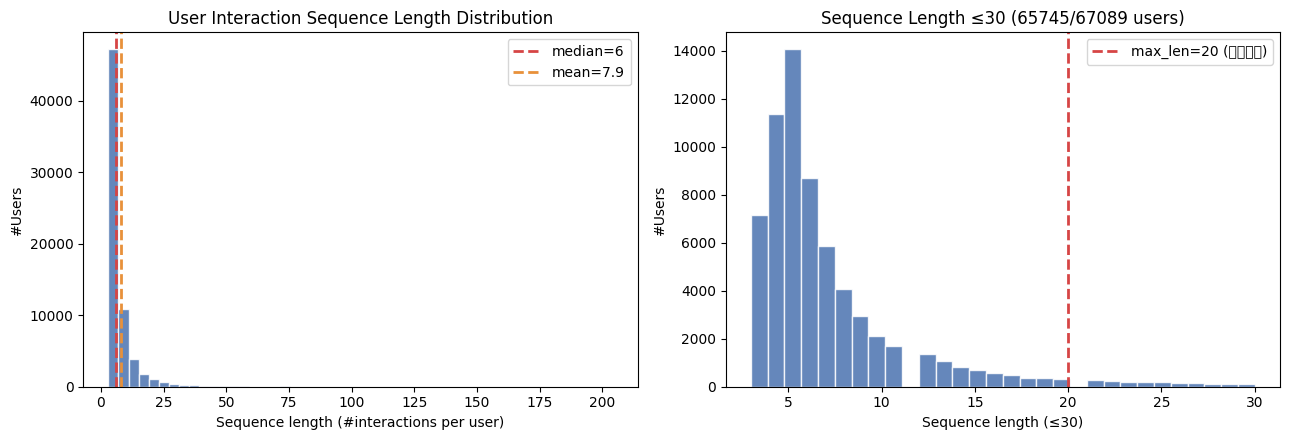


───────────────────────────────────────────────────────
  3. 滑动窗口展开 (训练集)
───────────────────────────────────────────────────────
  原始样本数: 22363
  展开后训练样本: 131410  (≈ 5.9x)

───────────────────────────────────────────────────────
  4. 类别分布
───────────────────────────────────────────────────────


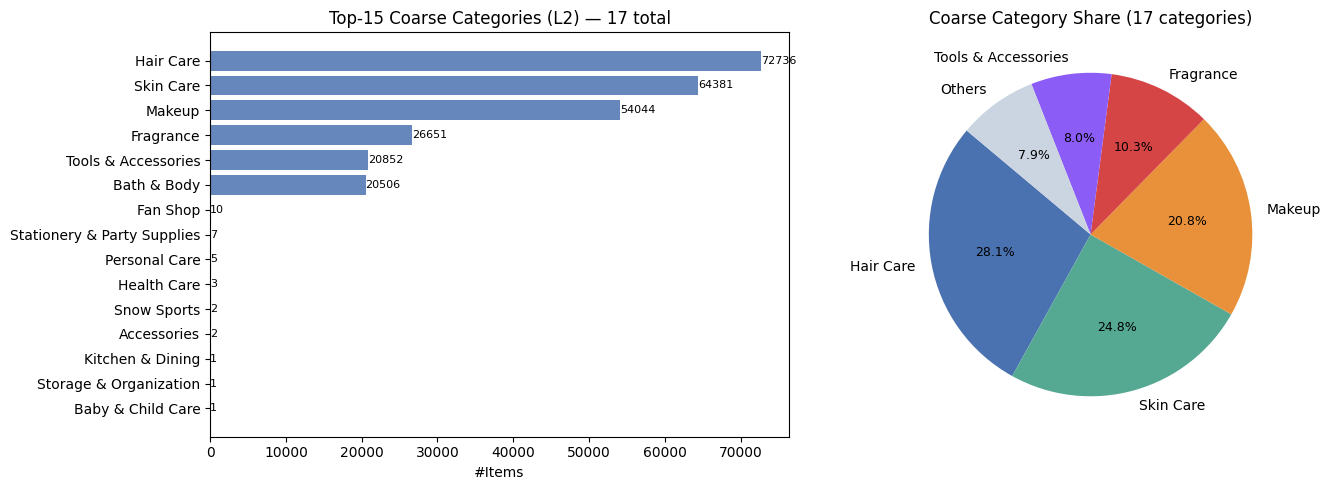

  Coarse categories (L2):  17
  Fine categories (L3+):   284
  Top-10 coarse:
    Hair Care                      72736 items  (28.1%)
    Skin Care                      64381 items  (24.8%)
    Makeup                         54044 items  (20.8%)
    Fragrance                      26651 items  (10.3%)
    Tools & Accessories            20852 items  (8.0%)
    Bath & Body                    20506 items  (7.9%)
    Fan Shop                          10 items  (0.0%)
    Stationery & Party Supplies        7 items  (0.0%)
    Personal Care                      5 items  (0.0%)
    Health Care                        3 items  (0.0%)

───────────────────────────────────────────────────────
  5. 用户活跃度
───────────────────────────────────────────────────────
  Min interactions: 3
  Max interactions: 202
  Mean: 6.9
  Median: 4

───────────────────────────────────────────────────────
  6. 物品流行度
───────────────────────────────────────────────────────
  总交互物品数: 12068
  Min popularity: 1
  Max populari

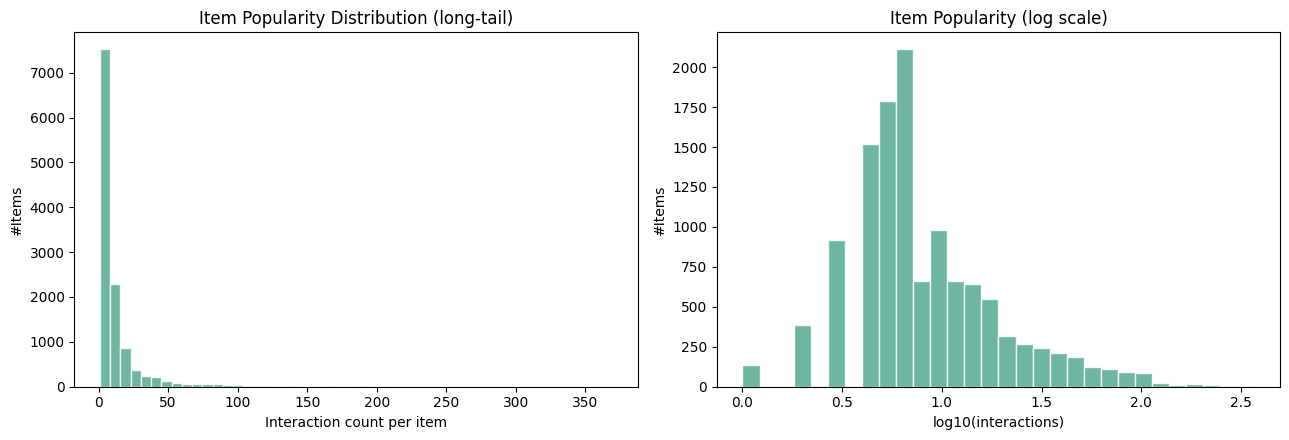


───────────────────────────────────────────────────────
  7. 长尾分析
───────────────────────────────────────────────────────
  Top 10% items cover: 69537/153773 = 45.2% interactions
  Top 50% items cover: 127342/153773 = 82.8% interactions
  Bottom 50% items cover: 26431/153773 = 17.2% interactions


In [7]:
# 看下数据分布
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from collections import Counter

dataset_name = "Beauty"

# ── 1. 加载数据 ──────────────────────────────────────────────────
train_df = pd.read_parquet(f'./{dataset_name}/train.parquet')
val_df   = pd.read_parquet(f'./{dataset_name}/valid.parquet')
test_df  = pd.read_parquet(f'./{dataset_name}/test.parquet')

with open(f'./{dataset_name}/{dataset_name}_metadata.json', 'r') as f:
    metadata = [json.loads(l) for l in f]

print("=" * 55)
print("  Beauty 数据集概览")
print("=" * 55)
print(f"  用户数:  {train_df['user'].nunique()}")
print(f"  物品数:  {len(itemID_mapping)}")
print(f"  交互数:  {len(train_df) + len(val_df) + len(test_df)}")
print(f"  训练样本: {len(train_df)}  (用户 × leave-one-out)")
print(f"  验证样本: {len(val_df)}")
print(f"  测试样本: {len(test_df)}")

# ── 2. 序列长度分布 ──────────────────────────────────────────────
print("\n" + "─" * 55)
print("  2. 序列长度分布 (原始用户交互序列)")
print("─" * 55)

seq_lengths = train_df['history'].apply(len) + 1  # +1 = history + target
# 合并所有 split 看完整序列
all_seqs = []
for df, name in [(train_df, 'train'), (val_df, 'valid'), (test_df, 'test')]:
    lengths = df['history'].apply(len) + 1
    all_seqs.extend(lengths.tolist())
    print(f"  {name}: min={lengths.min()}, max={lengths.max()}, "
          f"mean={lengths.mean():.1f}, median={lengths.median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(all_seqs, bins=50, edgecolor='white', color='#4A72B0', alpha=0.85)
ax.axvline(np.median(all_seqs), color='#D64545', linestyle='--', linewidth=2, label=f'median={np.median(all_seqs):.0f}')
ax.axvline(np.mean(all_seqs), color='#E8913A', linestyle='--', linewidth=2, label=f'mean={np.mean(all_seqs):.1f}')
ax.set_xlabel('Sequence length (#interactions per user)')
ax.set_ylabel('#Users')
ax.set_title('User Interaction Sequence Length Distribution')
ax.legend()

ax = axes[1]
# 只看 ≤30 的 (长尾之外)
masked = [l for l in all_seqs if l <= 30]
ax.hist(masked, bins=30, edgecolor='white', color='#4A72B0', alpha=0.85)
ax.axvline(20, color='#D64545', linestyle='--', linewidth=2, label='max_len=20 (截断阈值)')
ax.set_xlabel('Sequence length (≤30)')
ax.set_ylabel('#Users')
ax.set_title(f'Sequence Length ≤30 ({len(masked)}/{len(all_seqs)} users)')
ax.legend()

plt.tight_layout()
plt.savefig(f'./{dataset_name}/seq_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. 滑动窗口后训练样本数 ──────────────────────────────────────
print("\n" + "─" * 55)
print("  3. 滑动窗口展开 (训练集)")
print("─" * 55)

# 模拟 dataset.py 中的滑动窗口展开
expand_count = 0
for row in train_df.itertuples(index=False):
    seq = list(row.history) + [row.target]
    expand_count += len(seq) - 1  # for i in range(1, len(seq))

print(f"  原始样本数: {len(train_df)}")
print(f"  展开后训练样本: {expand_count}  (≈ {expand_count/len(train_df):.1f}x)")

# ── 4. 类别分布 ──────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  4. 类别分布")
print("─" * 55)

# 提取各类别层级
coarse_cats = []  # L2: major category
fine_cats = []    # L3+: full path
for m in metadata:
    cats = m.get('categories', [])
    if cats and len(cats) > 0:
        path = cats[0]
        if len(path) >= 2:
            coarse_cats.append(path[1])   # e.g. "Makeup"
        if len(path) >= 3:
            fine_cats.append(' > '.join(path[1:]))
        else:
            fine_cats.append(path[1] if len(path) >= 2 else path[0])
    else:
        coarse_cats.append('Unknown')

top_coarse = Counter(coarse_cats).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cats, counts = zip(*top_coarse)
bars = ax.barh(range(len(cats)), counts, color='#4A72B0', alpha=0.85)
ax.set_yticks(range(len(cats)))
ax.set_yticklabels(cats)
ax.invert_yaxis()
ax.set_xlabel('#Items')
ax.set_title(f'Top-15 Coarse Categories (L2) — {len(set(coarse_cats))} total')
for i, (c, v) in enumerate(zip(cats, counts)):
    ax.text(v + 2, i, str(v), va='center', fontsize=8)

ax = axes[1]
cat_counts = Counter(coarse_cats).most_common()
labels, values = zip(*cat_counts)
colors = ['#4A72B0', '#55A892', '#E8913A', '#D64545', '#8B5CF6',
          '#EC4899', '#F59E0B', '#06B6D4', '#84CC16', '#6366F1'][:5]
top5 = cat_counts[:5]
others = sum(v for _, v in cat_counts[5:])
wedges, texts, autotexts = ax.pie(
    [v for _, v in top5] + [others],
    labels=[k for k, _ in top5] + ['Others'],
    autopct='%1.1f%%',
    colors=colors[:len(top5)] + ['#CBD5E1'],
    startangle=140,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(f'Coarse Category Share ({len(set(coarse_cats))} categories)')

plt.tight_layout()
plt.savefig(f'./{dataset_name}/category_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Coarse categories (L2):  {len(set(coarse_cats))}")
print(f"  Fine categories (L3+):   {len(set(fine_cats))}")
print(f"  Top-10 coarse:")
for cat, cnt in top_coarse[:10]:
    print(f"    {cat:<30s} {cnt:>5d} items  ({cnt/len(coarse_cats)*100:.1f}%)")

# ── 5. 用户活跃度分布 ────────────────────────────────────────────
print("\n" + "─" * 55)
print("  5. 用户活跃度")
print("─" * 55)

user_activity = Counter()
for df in [train_df]:
    for row in df.itertuples(index=False):
        user_activity[row.user] += len(row.history) + 1  # +1 for target

acts = list(user_activity.values())
print(f"  Min interactions: {min(acts)}")
print(f"  Max interactions: {max(acts)}")
print(f"  Mean: {np.mean(acts):.1f}")
print(f"  Median: {np.median(acts):.0f}")

# ── 6. 物品流行度分布 ────────────────────────────────────────────
print("\n" + "─" * 55)
print("  6. 物品流行度")
print("─" * 55)

item_pop = Counter()
for df in [train_df]:
    for row in df.itertuples(index=False):
        for item in row.history:
            item_pop[item] += 1
        item_pop[row.target] += 1

pops = list(item_pop.values())
print(f"  总交互物品数: {len(item_pop)}")
print(f"  Min popularity: {min(pops)}")
print(f"  Max popularity: {max(pops)}")
print(f"  Mean: {np.mean(pops):.1f}")
print(f"  Median: {np.median(pops):.0f}")
print(f"  Items with ≤3 interactions: {sum(1 for p in pops if p <= 3)} ({sum(1 for p in pops if p <= 3)/len(pops)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(pops, bins=50, edgecolor='white', color='#55A892', alpha=0.85)
ax.set_xlabel('Interaction count per item')
ax.set_ylabel('#Items')
ax.set_title('Item Popularity Distribution (long-tail)')

ax = axes[1]
pop_log = np.log10(pops)
ax.hist(pop_log, bins=30, edgecolor='white', color='#55A892', alpha=0.85)
ax.set_xlabel('log10(interactions)')
ax.set_ylabel('#Items')
ax.set_title('Item Popularity (log scale)')

plt.tight_layout()
plt.savefig(f'./{dataset_name}/item_pop_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. 长尾分析 ──────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  7. 长尾分析")
print("─" * 55)

total_interactions = sum(pops)
top10_pct = sum(v for _, v in item_pop.most_common(int(len(item_pop) * 0.1)))
top50_pct = sum(v for _, v in item_pop.most_common(int(len(item_pop) * 0.5)))

print(f"  Top 10% items cover: {top10_pct}/{total_interactions} = {top10_pct/total_interactions*100:.1f}% interactions")
print(f"  Top 50% items cover: {top50_pct}/{total_interactions} = {top50_pct/total_interactions*100:.1f}% interactions")
print(f"  Bottom 50% items cover: {total_interactions - top50_pct}/{total_interactions} = {(total_interactions-top50_pct)/total_interactions*100:.1f}% interactions")

# Generate Item Semantic Embeddings

商品文本 → 语义向量（Sentence-T5）

**目标**：把每个商品的元数据（标一个 768 维的稠密向量。

**输入**：商品的文本描述。从 meta_Beauty.json.gz 成一段文本：
```
# 商品 ID=1 的实际数据
semantics = """
'title': WAWO 15 Colorw Camouflage FacialConcealer Neutral Palette
'price': 5.04
'salesRank': {'Beauty': 10486}
'brand': COKA
'categories': [['Beauty', 'Makeup', 'Face', 'Concealers & Neutralizers']]
"""
```

**编码**： [Sentence-T5-base](https://www.modelscope.cn/models/sentence-transformers/sentence-t5-base)

> 该模型仅使用了T5-base模型的编码器部分，权重以FP16格式存储。模型在句子相似性任务中表现良好，但在语义搜索任务中的表现并不理想。

"WAWO 15 Color Makeup..."
        ↓
Sentence-T5 (sentence-t5-base)
        ↓
768 维向量 [0.0058, -0.0332, ...]


**为什么用 Sentence-T5？**
1. Sentence-T5 直接是句子级别的语义建模，直接对整个句子/段落编码
2. 映射到这样的嵌入空间：语义相近的商品向量也相近
3. 固定维度输出，不管元数据文本多长，输出都是 768 维
4. 在大规模文本上预训练过，已经理解语言，无需微调，直接用作特征提取器

**输出**：

item_emb.parquet:  # 12101 行 × 2 列
  - ItemID: 1, 2, 3, ...
  - embedding: [0.0058, -0.0332, ..., 0.0123]  # 768 维

In [4]:
# Beauty metadata 
f = open(f"./{dataset_name}/{dataset_name}_metadata.json", 'w')
for l in parse(f"meta_{dataset_name}.json.gz"):
  f.write(l + '\n')

In [5]:
# Open the metadata file for reading
with open(f"./{dataset_name}/{dataset_name}_metadata.json", 'r') as metadata_file:
    # Create a reverse mapping from itemID to asin
    reverse_itemID_mapping = {v: k for k, v in itemID_mapping.items()}
    
    # Initialize a dictionary to store the extracted information
    item_info = {}
    
    # Process each line in the metadata file
    for line in metadata_file:
        metadata = json.loads(line.strip())
        asin = metadata.get('asin')
        
        # Check if the asin exists in the reverse mapping
        if asin in reverse_itemID_mapping.values():
            itemID = itemID_mapping[asin]
            item_info[itemID] = {
                'title': metadata.get('title') if metadata.get('title') else None,
                'price': metadata.get('price') if metadata.get('price') else None,
                'salesRank': metadata.get('salesRank') if metadata.get('salesRank') else None,
                'brand': metadata.get('brand') if metadata.get('brand') else None,
                'categories': metadata.get('categories') if metadata.get('categories') else None,
            }

# Print the information for the first 5 items
for itemID, info in list(item_info.items())[:5]:
    print(f"ItemID: {itemID}, Info: {info}")

ItemID: 1, Info: {'title': 'WAWO 15 Color Professionl Makeup Eyeshadow Camouflage Facial Concealer Neutral Palette', 'price': 5.04, 'salesRank': {'Beauty': 10486}, 'brand': 'COKA', 'categories': [['Beauty', 'Makeup', 'Face', 'Concealers & Neutralizers']]}
ItemID: 2, Info: {'title': 'Xtreme Brite Brightening Gel 1oz.', 'price': 19.99, 'salesRank': {'Beauty': 52254}, 'brand': 'Xtreme Brite', 'categories': [['Beauty', 'Hair Care', 'Styling Products', 'Creams, Gels & Lotions']]}
ItemID: 3, Info: {'title': 'Prada Candy By Prada Eau De Parfum Spray 1.7 Oz For Women', 'price': 65.86, 'salesRank': {'Beauty': 78916}, 'brand': 'Prada', 'categories': [['Beauty', 'Fragrance', "Women's", 'Eau de Parfum']]}
ItemID: 4, Info: {'title': 'Versace Bright Crystal Eau de Toilette Spray for Women, 3 Ounce', 'price': 52.33, 'salesRank': {'Beauty': 764}, 'brand': 'Versace', 'categories': [['Beauty', 'Fragrance', "Women's", 'Eau de Toilette']]}
ItemID: 5, Info: {'title': 'Stella McCartney Stella', 'price': Non

In [6]:
# 使用sentence-T5-base生成文本嵌入
from sentence_transformers import SentenceTransformer

# Initialize the SentenceTransformer model
#  modelscope download --model sentence-transformers/sentence-t5-base  --local_dir ./dir
model = SentenceTransformer('./sentence-t5-base')

# Prepare data for embedding
item_embeddings = []
for itemID, info in item_info.items():
    # Combine relevant fields into a single text for embedding
    semantics = f"'title':{info.get('title', '')}\n 'price':{info.get('price', '')}\n 'salesRank':{info.get('salesRank', '')}\n 'brand':{info.get('brand', '')}\n 'categories':{info.get('categories', '')}"
    embedding = model.encode(semantics)
    item_embeddings.append({'ItemID': itemID, 'embedding': embedding.tolist()})

# Convert to DataFrame
item_emb_df = pd.DataFrame(item_embeddings)

print("\nItem embeddings DataFrame shape:", item_emb_df.shape)
print("The first 3 rows of item embeddings DataFrame:\n", item_emb_df.head(3))

# Save to parquet file
item_emb_df.to_parquet(f'./{dataset_name}/item_emb.parquet', index=False)

print("Item embeddings saved to item_emb.parquet.")
# embeddings = np.array([item['embedding'] for item in item_embeddings])
# np.save(f'./{dataset_name}/item_emb.npy', embeddings)

# print("Item embeddings saved to item_emb.npy.")


Item embeddings DataFrame shape: (12101, 2)
The first 3 rows of item embeddings DataFrame:
    ItemID                                          embedding
0       1  [0.0058076647110283375, 0.0014257890870794654,...
1       2  [-0.005331166088581085, -0.03872958570718765, ...
2       3  [-0.033254243433475494, -0.030646521598100662,...
Item embeddings saved to item_emb.parquet.


In [6]:
# 使用 Qwen3-Embedding-0.6B 生成文本嵌入 (1024维)
# 通过硅基流动 (SiliconFlow) API 调用，OpenAI 兼容格式
#
# Qwen3-Embedding-0.6B:
#   - 1024 维输出 (vs Sentence-T5 的 768 维)
#   - 模型更大 (0.6B vs T5-base 220M)
#   - 中文/英文多语言优化
#   - 在 MTEB 基准上表现优于同尺寸模型
#
# 注意：运行前请填写下方的 API_KEY

import requests
import time
from tqdm import tqdm

# ============================================================
# 请在此处填写你的硅基流动 API Key
# ============================================================
API_KEY = ""
# ============================================================

API_BASE = "https://api.siliconflow.cn/v1/embeddings"
MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
BATCH_SIZE = 256  # 每批处理 256 个 item

headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
}


def make_semantics_text(info):
    """将 item 元数据组装为文本，与 Sentence-T5 版本完全一致。"""
    return (
        f"'title':{info.get('title', '')}\n"
        f"'price':{info.get('price', '')}\n"
        f"'salesRank':{info.get('salesRank', '')}\n"
        f"'brand':{info.get('brand', '')}\n"
        f"'categories':{info.get('categories', '')}"
    )


# 准备所有 item 的 (itemID, text) 对
items = []  # [(itemID, text), ...]
for itemID, info in item_info.items():
    text = make_semantics_text(info)
    items.append((itemID, text))

print(f"共 {len(items)} 个 item 待编码")
print(f"Batch size: {BATCH_SIZE}, 共 {len(items) // BATCH_SIZE + 1} 批")
print(f"模型: {MODEL_NAME}, 输出维度: 1024")

# 分批调用 API
all_embeddings = []
failed_ids = []

for i in tqdm(range(0, len(items), BATCH_SIZE), desc="Embedding"):
    batch = items[i:i + BATCH_SIZE]
    batch_ids = [item[0] for item in batch]
    batch_texts = [item[1] for item in batch]

    payload = {
        "model": MODEL_NAME,
        "input": batch_texts,
        "encoding_format": "float",
    }

    max_retries = 3
    for attempt in range(max_retries):
        try:
            resp = requests.post(API_BASE, headers=headers, json=payload, timeout=60)
            if resp.status_code == 200:
                data = resp.json()
                # OpenAI 兼容格式: {"data": [{"embedding": [...], "index": 0}, ...]}
                emb_list = sorted(data["data"], key=lambda x: x["index"])
                for item_id, emb_obj in zip(batch_ids, emb_list):
                    all_embeddings.append({
                        "ItemID": item_id,
                        "embedding": emb_obj["embedding"],
                    })
                break
            elif resp.status_code == 429:
                wait = 2 ** attempt
                tqdm.write(f"Rate limited, retry in {wait}s...")
                time.sleep(wait)
            else:
                tqdm.write(f"HTTP {resp.status_code}: {resp.text[:200]}")
                time.sleep(1)
        except Exception as e:
            tqdm.write(f"Request error (attempt {attempt+1}): {e}")
            time.sleep(2)

    else:
        # 全部重试失败
        failed_ids.extend(batch_ids)
        tqdm.write(f"Batch starting at item {batch_ids[0]} FAILED after {max_retries} tries")

if failed_ids:
    print(f"\n警告: {len(failed_ids)} 个 item 编码失败: {failed_ids[:10]}...")
else:
    print(f"\n全部 {len(all_embeddings)} 个 item 编码成功！")

# 转换为 DataFrame 并保存
item_emb_df = pd.DataFrame(all_embeddings)

print(f"Item embeddings DataFrame shape: {item_emb_df.shape}")
print(f"Embedding 维度: {len(item_emb_df.iloc[0]['embedding'])}")
print(f"The first 3 rows:\n{item_emb_df.head(3)}")

# 保存为 parquet
item_emb_df.to_parquet(f'./{dataset_name}/item_emb_from_qwen3_0.6B.parquet', index=False)
print(f"\nItem embeddings saved to ./{dataset_name}/item_emb_from_qwen3_0.6B.parquet")

共 12101 个 item 待编码
Batch size: 256, 共 48 批
模型: Qwen/Qwen3-Embedding-0.6B, 输出维度: 1024


Embedding: 100%|██████████| 48/48 [01:15<00:00,  1.58s/it]



全部 12101 个 item 编码成功！
Item embeddings DataFrame shape: (12101, 2)
Embedding 维度: 1024
The first 3 rows:
   ItemID                                          embedding
0       1  [-0.02261727675795555, -0.02385415881872177, -...
1       2  [-0.04952280595898628, 0.040840234607458115, -...
2       3  [-0.015961427241563797, 0.051018256694078445, ...

Item embeddings saved to ./Beauty/item_emb_from_qwen3_0.6B.parquet
